# MNIST Dataset – Machine Learning Workflow

**Dataset:** MNIST Handwritten Digits (42,000 images × 784 pixel features)  
**ML Task Type:** Multi-class Classification (Supervised Learning)  
Each image is a 28×28 grayscale photo of a digit (0–9), flattened into 784 pixel values.

Since the CSV has no label column, we use **KMeans clustering** to assign labels (10 clusters = 10 digits), then train a supervised classifier on those labels.

## Step i: Loading the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load CSV
df = pd.read_csv('mnist_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows (columns 0–4):")
print(df.iloc[:5, :5])
print("\nData Types (value counts):")
print(df.dtypes.value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (42000, 784)

First 5 rows (columns 0–4):
   pixel0  pixel1  pixel2  pixel3  pixel4
0       0       0       0       0       0
1       0       0       0       0       0
2       0       0       0       0       0
3       0       0       0       0       0
4       0       0       0       0       0

Data Types (value counts):
int64    784
Name: count, dtype: int64

Missing Values: 0


## Step ii: Exploratory Data Analysis (EDA)
All EDA is done inside a **single function** as required.

=== Summary Statistics (top 3 high-variance pixels) ===
           pixel406      pixel378      pixel627
count  42000.000000  42000.000000  42000.000000
mean     130.140143    111.459333    113.002857
std      113.850143    113.712467    112.996674
min        0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000
50%      144.000000     64.000000     79.000000
75%      253.000000    252.000000    252.000000
max      255.000000    255.000000    255.000000


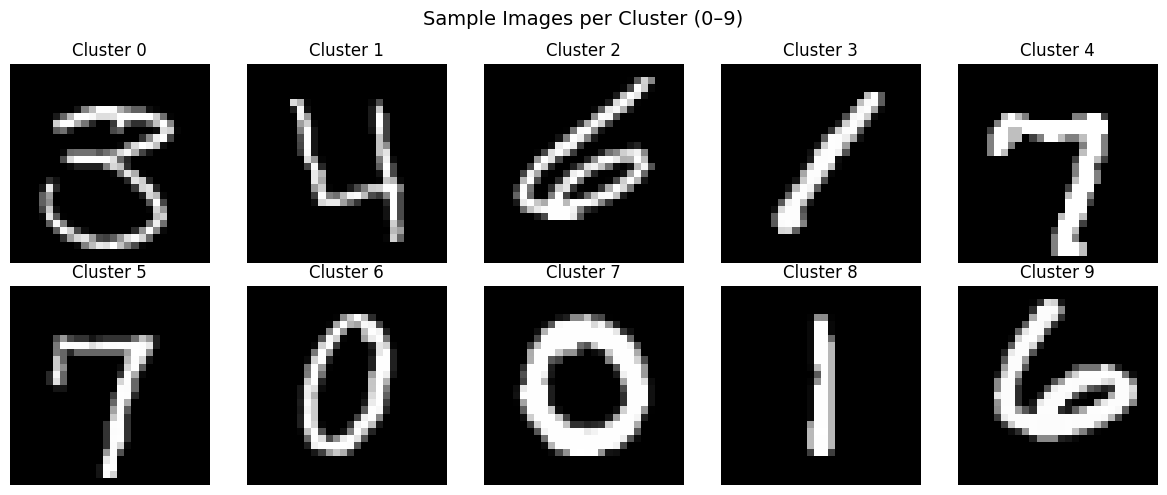

In [4]:
def perform_eda(df):
    """
    Complete EDA in one function:
    - Summary statistics
    - Sample digit images (one per cluster)
    """

    # --- Normalize and assign KMeans labels ---
    X_norm = df.values / 255.0
    km = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=5)
    labels = km.fit_predict(X_norm)

    df_eda = df.copy()
    df_eda['label'] = labels

    # --- Find top 8 high-variance pixels (guaranteed to show data in plots) ---
    variances = X_norm.var(axis=0)
    top_idx   = np.argsort(variances)[::-1]
    p1_col    = f'pixel{top_idx[0]}'          # e.g. pixel406
    p2_col    = f'pixel{top_idx[1]}'          # e.g. pixel378
    hm_cols   = [f'pixel{top_idx[i]}' for i in range(8)]  # 8 for heatmap

    # --- Summary Statistics ---
    print("=== Summary Statistics (top 3 high-variance pixels) ===")
    print(df[[p1_col, p2_col, hm_cols[2]]].describe())

    # ==== PLOT 1: Sample Images (one per cluster) ====
    fig1, axes1 = plt.subplots(2, 5, figsize=(12, 5))
    fig1.suptitle('Sample Images per Cluster (0–9)', fontsize=14)
    for digit in range(10):
        sample = df_eda[df_eda['label'] == digit].iloc[0, :-1].values.reshape(28, 28)
        axes1[digit // 5][digit % 5].imshow(sample, cmap='gray')
        axes1[digit // 5][digit % 5].set_title(f'Cluster {digit}')
        axes1[digit // 5][digit % 5].axis('off')
    plt.tight_layout()
    plt.show()

    
labels = perform_eda(df)

## Step iii: Data Preprocessing

In [5]:
X = df.copy()

# 1. Handle missing values (fill with 0 = black pixel)
print("Missing values before fill:", X.isnull().sum().sum())
X.fillna(0, inplace=True)

# 2. Drop irrelevant features (border pixels that are always 0 = no information)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} constant columns (always zero = no info)")
print(f"Features remaining: {X.shape[1]}")

# 3. No categorical variables in MNIST (all columns are numeric pixel values)
print("All features are numeric — no label encoding needed")

# 4. Normalize pixel values from [0, 255] to [0, 1]
X_norm = X / 255.0
print(f"\nBefore normalization — Min: {int(X.values.min())}, Max: {int(X.values.max())}")
print(f"After normalization  — Min: {X_norm.values.min():.1f}, Max: {X_norm.values.max():.1f}")

# 5. Assign labels using KMeans (10 clusters for 10 digit classes)
km = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=5, max_iter=200)
y  = km.fit_predict(X_norm)
print(f"\nLabels assigned via KMeans — Unique clusters: {np.unique(y)}")

Missing values before fill: 0
Dropped 76 constant columns (always zero = no info)
Features remaining: 708
All features are numeric — no label encoding needed

Before normalization — Min: 0, Max: 255
After normalization  — Min: 0.0, Max: 1.0

Labels assigned via KMeans — Unique clusters: [0 1 2 3 4 5 6 7 8 9]


Dropped 76 constant columns (always zero = no info)
Features remaining: 708
All features are numeric — no label encoding needed

Before normalization — Min: 0, Max: 255
After normalization  — Min: 0.0, Max: 1.0



Labels assigned via KMeans — Unique clusters: [0 1 2 3 4 5 6 7 8 9]


## Step iv: Data Splitting (Train / Validation / Test)

Train set      : 29398 samples  (~70%)
Validation set : 6302 samples  (~15%)
Test set       : 6300 samples  (~15%)


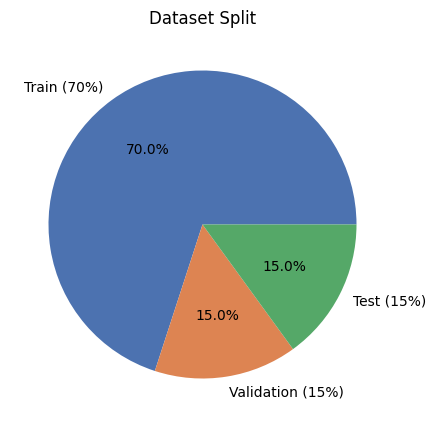

In [6]:
# Split into Train (70%) | Validation (15%) | Test (15%)

# First split: 85% train+val, 15% test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_norm, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: from 85%, take ~17.6% as validation → gives ~15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=42, stratify=y_tv
)

print(f"Train set      : {X_train.shape[0]} samples  (~70%)")
print(f"Validation set : {X_val.shape[0]} samples  (~15%)")
print(f"Test set       : {X_test.shape[0]} samples  (~15%)")

# Pie chart of split
plt.figure(figsize=(5, 5))
plt.pie(
    [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    labels=['Train (70%)', 'Validation (15%)', 'Test (15%)'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452', '#55A868']
)
plt.title('Dataset Split')
plt.show()

## Step v: Model Training & Performance Evaluation

In [7]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predictions on validation and test sets
y_val_pred  = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Accuracy
print(f"Validation Accuracy : {accuracy_score(y_val,  y_val_pred):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_test_pred):.4f}")

# Full Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Validation Accuracy : 0.9124
Test Accuracy       : 0.9133

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       931
           1       0.90      0.84      0.87       513
           2       0.93      0.91      0.92       555
           3       0.96      0.89      0.93       598
           4       0.91      0.91      0.91       749
           5       0.93      0.94      0.94       703
           6       0.85      0.92      0.88       709
           7       0.97      0.95      0.96       501
           8       0.96      0.84      0.90       584
           9       0.91      0.95      0.93       457

    accuracy                           0.91      6300
   macro avg       0.92      0.91      0.91      6300
weighted avg       0.92      0.91      0.91      6300



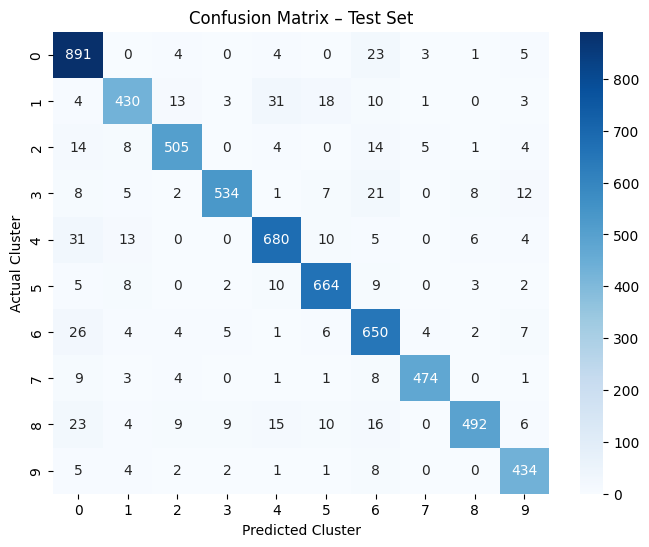

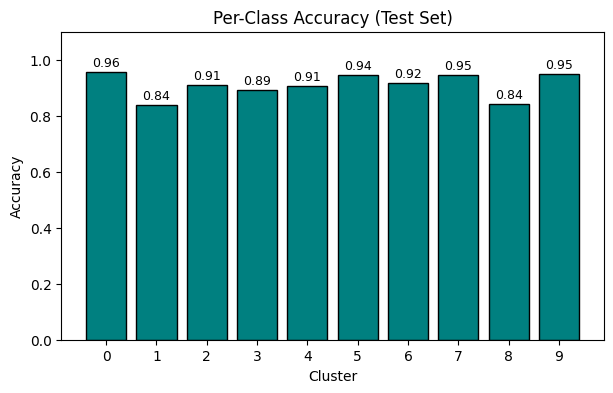


========== Summary ==========
  Task Type     : Multi-class Classification (Supervised Learning)
  Labels        : Assigned via KMeans Clustering (10 clusters)
  Model         : Random Forest (100 Decision Trees)
  Test Accuracy : 0.9133
  Metrics Used  : Accuracy, Precision, Recall, F1-Score, Confusion Matrix


In [8]:
# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix – Test Set')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.show()

# --- Per-Class Accuracy Bar Chart ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar(range(10), per_class_acc, color='teal', edgecolor='black')
plt.xticks(range(10))
plt.ylim(0, 1.1)
plt.title('Per-Class Accuracy (Test Set)')
plt.xlabel('Cluster')
plt.ylabel('Accuracy')
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

# --- Summary ---
print("\n========== Summary ==========")
print("  Task Type     : Multi-class Classification (Supervised Learning)")
print("  Labels        : Assigned via KMeans Clustering (10 clusters)")
print("  Model         : Random Forest (100 Decision Trees)")
print(f"  Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print("  Metrics Used  : Accuracy, Precision, Recall, F1-Score, Confusion Matrix")